## Manual annotation using gene expression

In [1]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_py_analysis
# python -m ipykernel install --user --name scrna_cartography_py_analysis --display-name "py_analysis"

In [2]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pathlib import Path     # Object-oriented filesystem paths
from pyhere import here      # Reproducible project paths

# Single-cell data handling
import anndata as ad            # Core data structure for single-cell data
import scanpy as sc          # Analysis and visualization of single-cell data


# dataframes
import pandas as pd

# Micellaneous utilities
import warnings              # Suppress or manage warnings

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import my_anndata as ma                    # Custom AnnData utilities
import misc as mi

In [3]:
# Paths
base_dir = str(here('data/annotate/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 

anndata_dir = str(here('data/anndata/'))
harmo_dir = Path(here('data/marker_database/harmonized'))

Load data

In [4]:
adata = ad.read_h5ad(os.path.join(anndata_dir, "AG_combined.h5ad"))

In [5]:
# azimuth markers
azi_markers = pd.read_csv(os.path.join(harmo_dir, 'azimuth_genes.csv'), sep=",", dtype=str) 
# Remove genes that are not in var names
azi_markers = azi_markers[azi_markers['gene'].isin(adata.var_names)]
# make to dictionary
azi_markers = azi_markers.groupby('cell_type')['gene'].apply(list).apply(list).to_dict()

In [6]:
# pangola markers
pan_markers = pd.read_csv(os.path.join(harmo_dir, 'panglao_genes.csv'), sep=",", dtype=str) 
# Remove genes that are not in var names
pan_markers = pan_markers[pan_markers['gene'].isin(adata.var_names)]
# make to dictionary
pan_markers = pan_markers.groupby('cell_type')['gene'].apply(list).apply(list).to_dict()

In [7]:
# cellmarker markers
cell_markers = pd.read_csv(os.path.join(harmo_dir, 'cellmarker_genes.csv'), sep=",", dtype=str) 
# Remove genes that are not in var names
cell_markers = cell_markers[cell_markers['gene'].isin(adata.var_names)]
# make to dictionary
cell_markers = cell_markers.groupby('cell_type')['gene'].apply(list).apply(list).to_dict()

Find clusters (run until optimal clustering is found)

In [8]:
sc.tl.leiden(adata, n_iterations=-1, flavor = 'igraph', random_state= 1000)

Save object with leiden

In [9]:
adata.write(os.path.join(anndata_dir, "AG_combined.h5ad"))

Marker gene expression

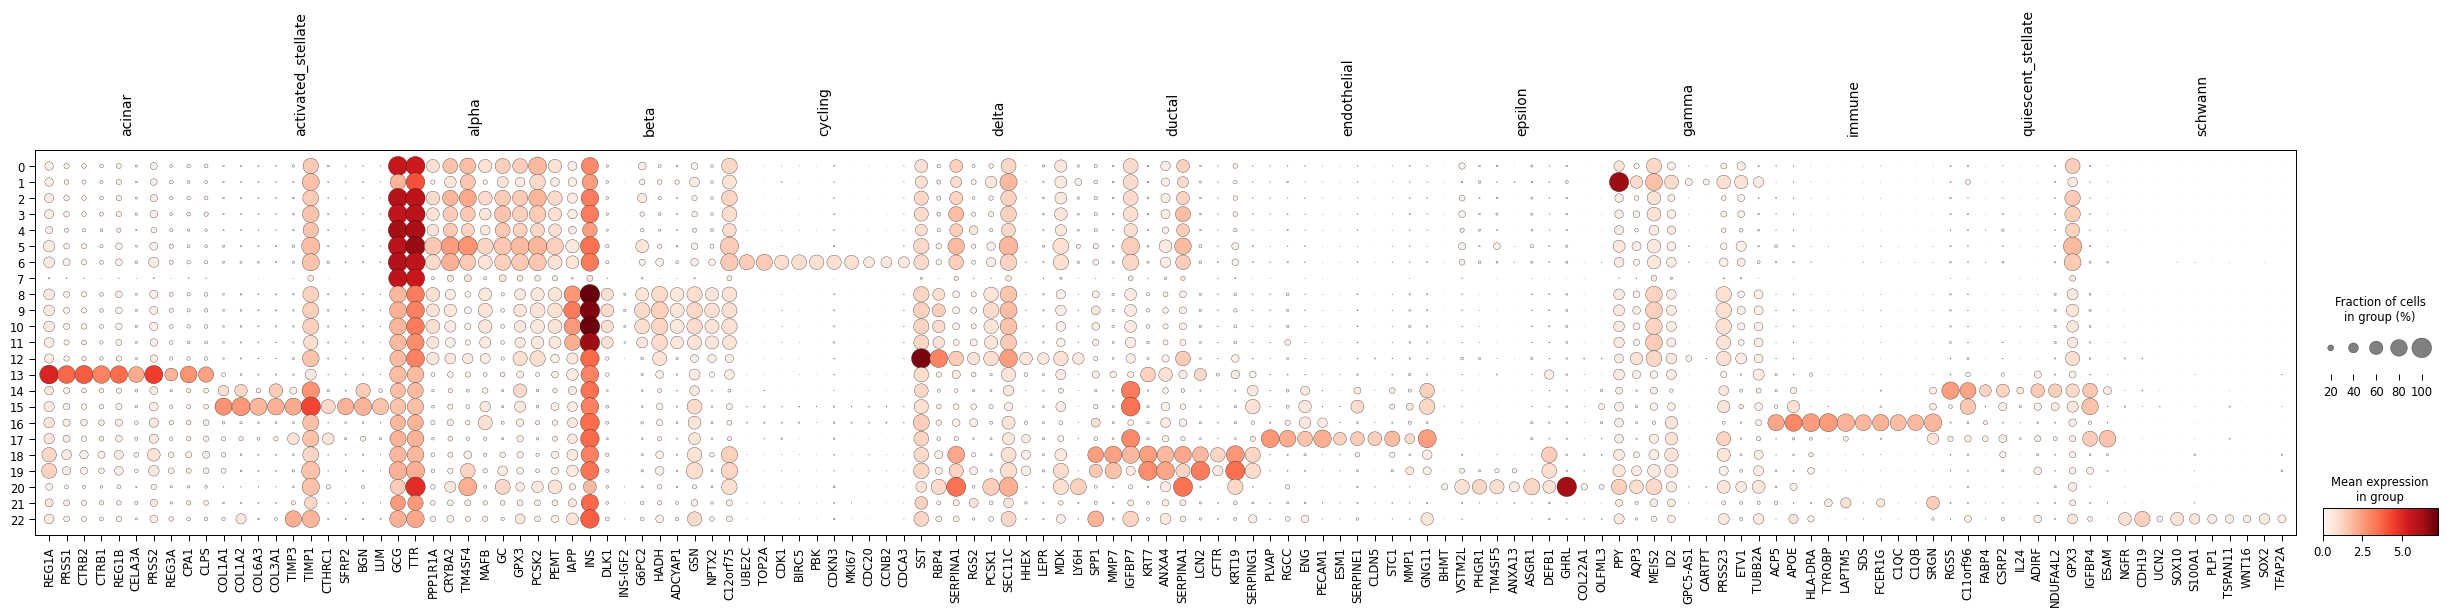

In [10]:
mi.set_my_theme()
fig = sc.pl.dotplot(adata, azi_markers, groupby = 'leiden', return_fig= True, show= False, figsize= (31,5))
fig.savefig(os.path.join(plot_dir, "manual_annotation_azimuth_dotplot.pdf"), bbox_inches="tight")

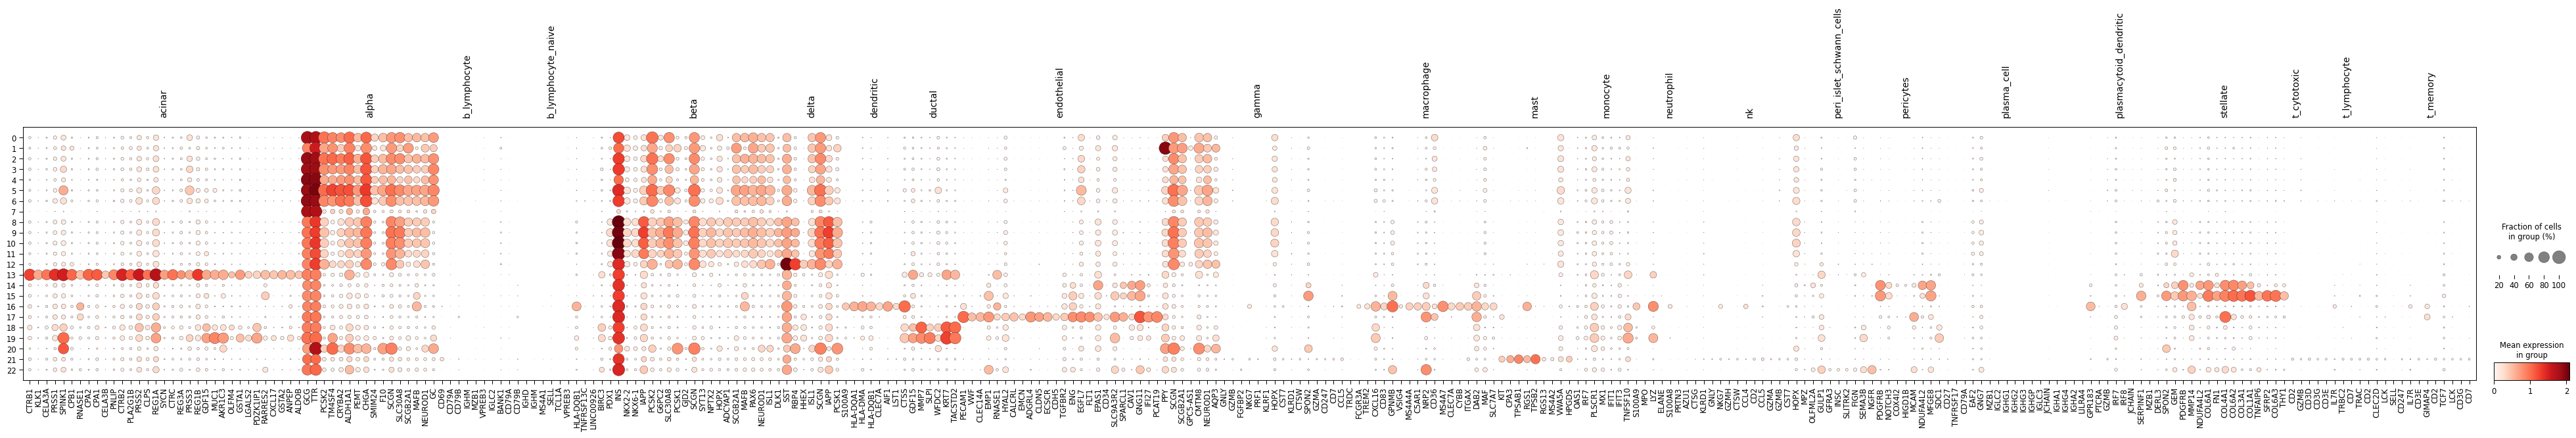

In [11]:
mi.set_my_theme()
fig = sc.pl.dotplot(adata, pan_markers, groupby = 'leiden', return_fig= True, show= False, figsize= (50,5), log = True)
fig.savefig(os.path.join(plot_dir, "manual_annotation_panglao_dotplot.pdf"), bbox_inches="tight")

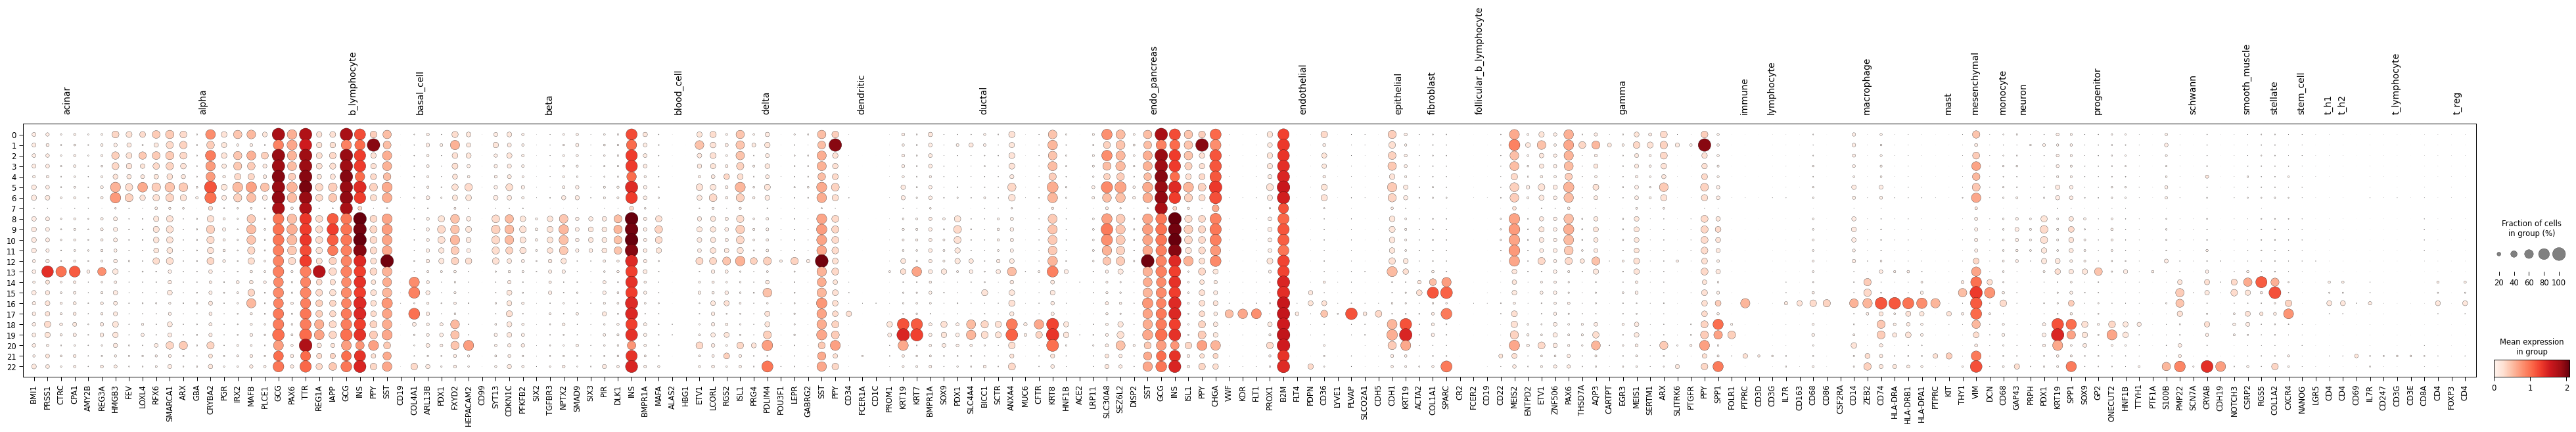

In [12]:
mi.set_my_theme()
fig = sc.pl.dotplot(adata, cell_markers, groupby = 'leiden', return_fig= True, show= False, figsize= (50,5), log = True)
fig.savefig(os.path.join(plot_dir, "manual_annotation_cellmarker_dotplot.pdf"), bbox_inches="tight")

Do manual annotation based on marker genes expressions

In [13]:
# create a dictionary to map cluster to annotation label
cluster2annotation = {
    "0": "alpha",
    "1": "gamma",
    "2": "alpha",
    "3": "alpha",
    "4": "alpha",
    "5": "alpha",
    "6": "cycling",
    "7": "alpha",
    "8": "beta",
    "9": "beta",
    "10": "beta",
    "11": "beta",
    "12": "delta",
    "13": "acinar",
    "14": "quiescent_stellate",
    "15": "activated_stellate",
    "16": "macrophage",
    "17": "endothelial",
    "18": "ductal",
    "19": "ductal",
    "20": "epsilon",
    "21": "mast",
    "22": "schwann"
}

# add a new `.obs` column called `cell type` by mapping clusters to annotation using pandas `map` function
adata.obs["manual_annotation"] = adata.obs["leiden"].map(cluster2annotation).astype("category")

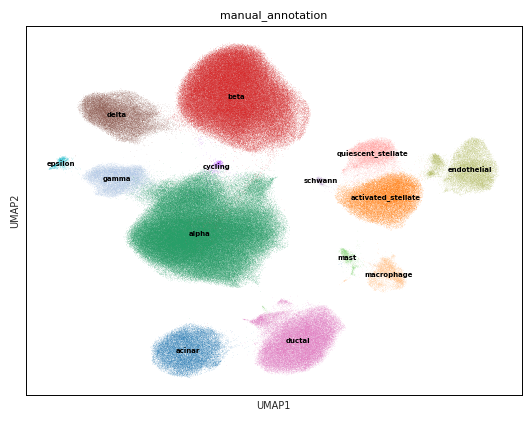

In [14]:
sc.pl.umap(adata, color = "manual_annotation", legend_loc= "on data", legend_fontsize= 5)

Save object and leiden clusters and manual annotation

In [15]:
clustering = adata.obs.loc[:,adata.obs.columns.str.startswith('leiden')].copy()
clustering.to_csv(os.path.join(files_dir, 'leiden_clusterings_igraph.csv'), index_label='barcode')

In [16]:
manual_anno = adata.obs.loc[:,adata.obs.columns.str.startswith('manual_annotation')].copy()
manual_anno.to_csv(os.path.join(files_dir, 'manual_annotation.csv'), index_label='barcode')

Scale expression of marker genes

In [17]:
# marker genes
# path to marker genes
genelists_path = glob.glob(os.path.join(harmo_dir, '*.csv'))

genelists = {}

for file in genelists_path:
    name = Path(file).stem.replace('_genes', '')
    df = pd.read_csv(file, sep=",", dtype=str)
    df_grouped = df.groupby('cell_type')['gene'].apply(list)
    for celltype, genes in df_grouped.items():
        key = f"{name}_{celltype}"
        genelists[key] = genes

genes_to_scale = []

for _, genes in genelists.items():
    genes_to_scale.extend(genes)

# get unique
genes_to_scale = list(set(genes_to_scale))

In [18]:
idx = adata.var_names.isin(genes_to_scale)
adata_sub = adata[:, idx].copy()
scaled_subset = sc.pp.scale(adata_sub, copy=True).X
adata_sub.layers["scaled"] = scaled_subset

/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


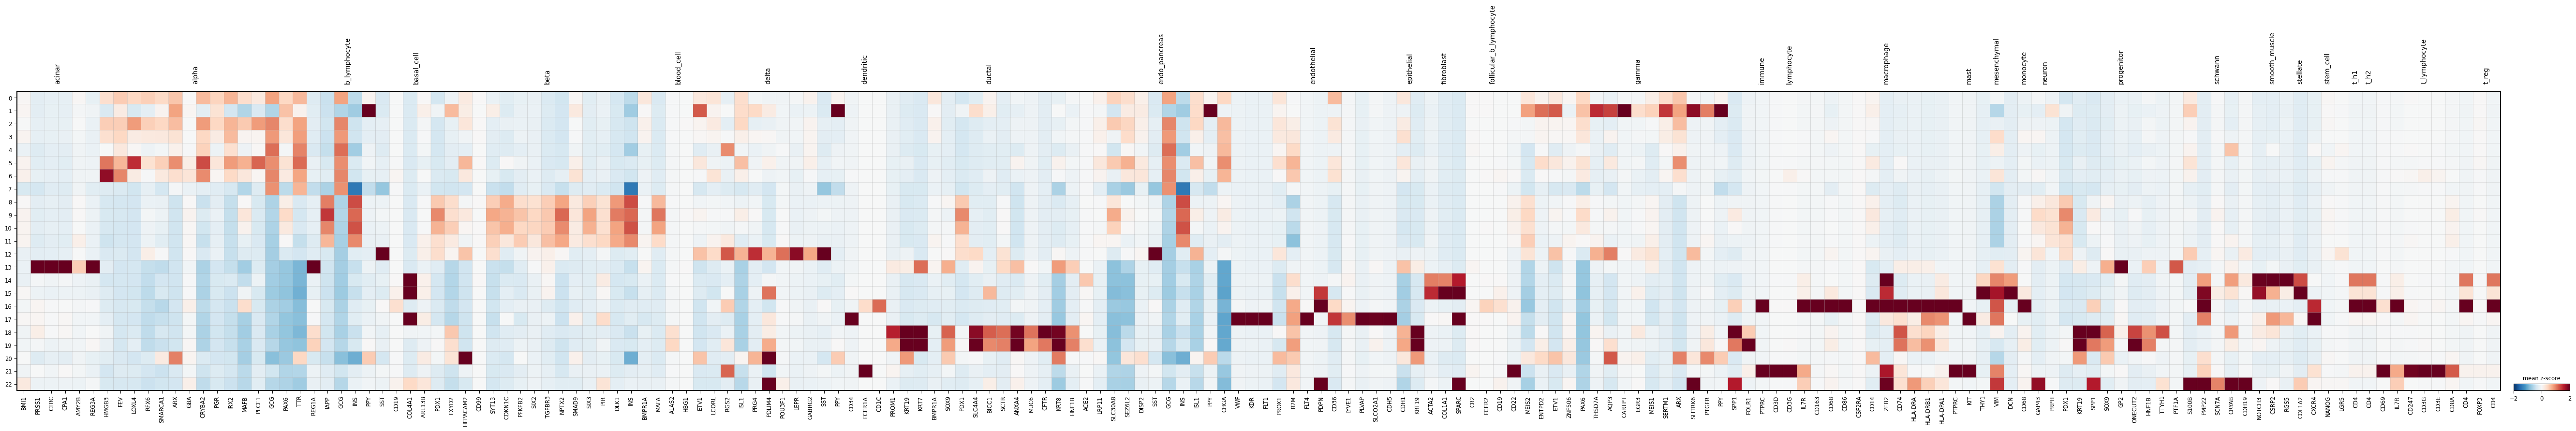

In [19]:
sc.pl.matrixplot(
    adata_sub,
    cell_markers,
    "leiden",
    colorbar_title="mean z-score",
    layer="scaled", 
    vmin=-2,
    vmax=2,
    cmap="RdBu_r",
)

In [21]:
pan_markers.keys()

dict_keys(['acinar', 'alpha', 'b_lymphocyte', 'b_lymphocyte_naive', 'beta', 'delta', 'dendritic', 'ductal', 'endothelial', 'gamma', 'macrophage', 'mast', 'monocyte', 'neutrophil', 'nk', 'peri_islet_schwann_cells', 'pericytes', 'plasma_cell', 'plasmacytoid_dendritic', 'stellate', 't_cytotoxic', 't_lymphocyte', 't_memory'])